# Импорты

In [1]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import RegularGridInterpolator

In [3]:
from pymatgen.core import Structure

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar
from pymatgen.io.vasp.outputs import Chgcar
from pymatgen.io.vasp.outputs import Locpot

from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from pymatgen.electronic_structure.core import Spin

In [4]:
import warnings

In [5]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [6]:
# VASP_run_02
Ni3Al_02_start_structure = Structure.from_file("Ni3Al/POSCAR")
Ni3Al_02_optimized_structure = Structure.from_file("Ni3Al/result/CONTCAR")
Ni3Al_02_Outcar = Outcar("Ni3Al/result/OUTCAR")
Ni3Al_02_vasprun = Vasprun("Ni3Al/result/vasprun.xml")
Ni3Al_02_INCAR = Incar.from_file("Ni3Al/INCAR")
Ni3Al_02_CHGCAR = Chgcar.from_file("Ni3Al/result/CHGCAR")
Ni3Al_02_LOCPOT = Locpot.from_file("Ni3Al/result/LOCPOT")

In [7]:
# VASP_run_01 - Ni3Al для сравнения
Ni3Al_01_start_structure = Structure.from_file("../VASP_run_01/Ni3Al/POSCAR")
Ni3Al_01_optimized_structure = Structure.from_file("../VASP_run_01/Ni3Al/result/CONTCAR")
Ni3Al_01_INCAR = Incar.from_file("../VASP_run_01/Ni3Al/INCAR")
Ni3Al_01_Outcar = Outcar("../VASP_run_01/Ni3Al/result/OUTCAR")
Ni3Al_01_vasprun = Vasprun("../VASP_run_01/Ni3Al/result/vasprun.xml")

# VASP_run_01 - Al и Ni для вычисления энтальпии образования
Ni_01_Outcar = Outcar("../VASP_run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../VASP_run_01/Al/result/OUTCAR")

# Параметры расчета

In [8]:
pd.set_option('display.float_format', '{:.2e}'.format)

df_incar = pd.DataFrame({
    'Ni3Al (VASP_run_02)': dict(Ni3Al_02_INCAR),
    'Ni3Al (VASP_run_01)': dict(Ni3Al_01_INCAR)
}).fillna('')

df_incar

,Ni3Al (VASP_run_02),Ni3Al (VASP_run_01)
SYSTEM,Ni3Al L12 2x2x2 supercell,Ni3Al L12
PREC,Accurate,Accurate
NCORE,4,4
LREAL,False,False
LWAVE,False,False
SYMPREC,1.00e-05,1.00e-05
ISYM,2,2
ISPIN,2,2
MAGMOM,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, ...","[0.0, 0.2, 0.2, 0.2]"
ISMEAR,1,1


> Расчёт VASP_run_02 выполнен для суперячейки 2×2×2 с ужесточёнными критериями сходимости: электронная сходимость EDIFF задана как 1e-8 (против 1e-7 в VASP_run_01), а критерий остановки ионной релаксации EDIFFG составляет -0.001 эВ/Å (вдвое строже, чем -0.005 в VASP_run_01). Кроме того, VASP_run_02 включает дополнительные выходные параметры: LORBIT = 11 и RWIGS для проекционного анализа плотности состояний, LVHAR = .TRUE. для записи локального потенциала, LCHARG = .TRUE. для сохранения зарядовой плотности и NWRITE = 3 для детального вывода в OUTCAR; также увеличено число точек NEDOS до 5000 для более гладкой DOS. В свою очередь, VASP_run_01 для элементарной ячейки полагается на автоматическое построение k-сетки через KSPACING = 0.1 (в VASP_run_02 этот параметр отсутствует - сетка задаётся явно в KPOINTS).

# Сходимость электронного и ионного цикла

In [9]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([{**outcar.run_stats, 'System': name} for name, outcar in [('Ni3Al VASP_run_02', Ni3Al_02_Outcar), ('Ni3Al VASP_run_01', Ni3Al_01_Outcar)]])
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores,System
0,None,279368.0,59428.12,2455.877,56865.294,59321.172,24,Ni3Al VASP_run_02
1,None,140384.0,329.6,27.159,294.641,321.8,24,Ni3Al VASP_run_01


> Из приведённых данных о вычислительных ресурсах видно, что **расчёт `VASP_run_02` оказался существенно затратнее** по всем параметрам. Он использовал почти вдвое больше оперативной памяти (`Maximum memory used` — 279 Мбайт против 140 Мбайт в `VASP_run_01`) и потребовал значительно больше времени: **16 часов 30 минут** против 5 минут 30 секунд в `VASP_run_01`. Это напрямую связано с тем, что `VASP_run_02` выполнялся для суперячейки 2×2×2, с ужесточёнными критериями сходимости (`EDIFF = 1e-8` и `EDIFFG = -0.001`), а также с включением дополнительных вычислений (проекционная DOS, запись потенциала и зарядовой плотности).

## Электронный цикл

In [10]:
Ni3Al_02_steps = Ni3Al_02_vasprun.ionic_steps

In [11]:
data_02 = []
es = Ni3Al_02_steps[-1]['electronic_steps']
for i in range(1, len(es)):
    d = abs(es[i]['e_fr_energy'] - es[i-1]['e_fr_energy'])
    data_02.append({'Итерация': i, '|ΔE| (эВ)': d})

df_02_delta_e = pd.DataFrame(data_02)

df_02_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

Итерация,|ΔE| (эВ)
1,0.0010166500
2,0.0035971400
3,0.0000673200
4,0.0000052600
5,0.0000022500
6,0.0000005800
7,0.0000003800
8,0.0000000700
9,0.0000009700
10,0.0000003500


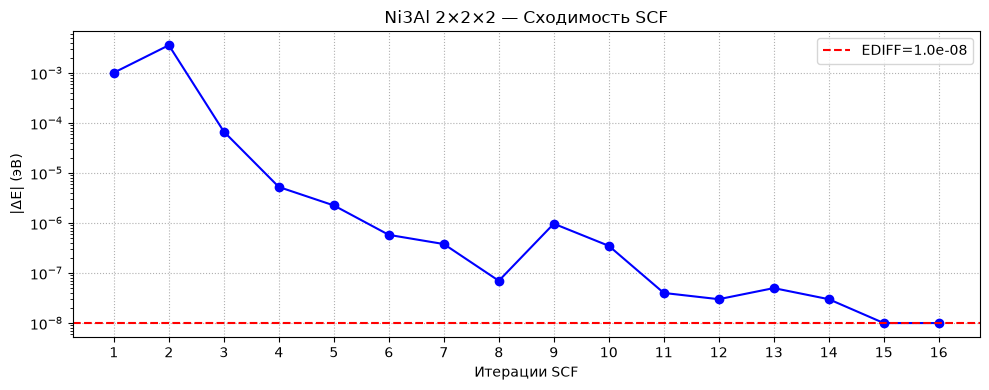

In [12]:
EDIFF_02 = Ni3Al_02_INCAR.get('EDIFF')

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_02_delta_e['Итерация'], df_02_delta_e['|ΔE| (эВ)'], 'o-', color='b')
ax.axhline(EDIFF_02, color='r', linestyle='--', label=f'EDIFF={EDIFF_02:.1e}')
ax.set_yscale('log')
ax.set_xlabel('Итерации SCF')
ax.set_ylabel('|ΔE| (эВ)')
ax.set_title('Ni3Al 2×2×2 — Сходимость SCF')
ax.grid(linestyle=':')
ax.legend()
max_iter = df_02_delta_e['Итерация'].max()
ax.set_xticks(range(1, max_iter + 1))

plt.tight_layout()
plt.show()

## Ионный цикл

In [13]:
data_02_ion_forces = []
for i, step in enumerate(Ni3Al_02_steps):
    forces = step['forces']
    max_force = max(abs(f) for atom in forces for f in atom)
    data_02_ion_forces.append({'Ионный шаг': i, '|F_max| (эВ/Å)': max_force})

df_02_ion_forces = pd.DataFrame(data_02_ion_forces)
df_02_ion_forces

,Ионный шаг,|F_max| (эВ/Å)
0,0,0.0
1,1,0.0
2,2,0.0


> **Примечание по ионной сходимости**     
> Расчёт содержал 3 ионных шага (шаг 0 — начальный SCF, шаги 1 и 2 — релаксация). Силы на все атомы практически нулевые на каждом шаге, поскольку стартовая структура (L1₂ Ni₃Al) задана в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии. Расчёт сошёлся за 2 шага релаксации, ионы не двигались.

# Кристаллографические парамеры

In [14]:
# [VASP_run_02] Начальный параметр решетки
Ni3Al_02_a = Ni3Al_02_start_structure.lattice.a

# [VASP_run_02] Оптимизированный параметр решетки
Ni3Al_02_a_opt = Ni3Al_02_optimized_structure.lattice.a

# [VASP_run_02] Начальный объем
Ni3Al_02_volume = Ni3Al_02_start_structure.volume

# [VASP_run_02] Оптимизированный объем
Ni3Al_02_volume_opt = Ni3Al_02_optimized_structure.volume

# [VASP_run_02] Пространственная группа
Ni3Al_02_Space_Group = SpacegroupAnalyzer(Ni3Al_02_optimized_structure, 0.1).get_space_group_symbol()

In [15]:
# [VASP_run_01] Начальный параметр решетки
Ni3Al_01_a = Ni3Al_01_start_structure.lattice.a

# [VASP_run_01] Оптимизированный параметр решетки
Ni3Al_01_a_opt = Ni3Al_01_optimized_structure.lattice.a

# [VASP_run_01] Начальный объем
Ni3Al_01_volume = Ni3Al_01_start_structure.volume

# [VASP_run_01] Оптимизированный объем
Ni3Al_01_volume_opt = Ni3Al_01_optimized_structure.volume

# [VASP_run_01] Пространственная группа
Ni3Al_01_Space_Group = SpacegroupAnalyzer(Ni3Al_01_optimized_structure, 0.1).get_space_group_symbol()


In [16]:
data_crystal_02 = {
    'Система': [
        'Ni3Al эл.ячейка',
        'Ni3Al 2×2×2'
    ],
    'Группа': [Ni3Al_01_Space_Group, Ni3Al_02_Space_Group],
    'a старт. (Å)': [Ni3Al_01_a, Ni3Al_02_a],
    'a опт. (Å)': [Ni3Al_01_a_opt, Ni3Al_02_a_opt],
    'Δa (%)': [
        (Ni3Al_01_a_opt - Ni3Al_01_a) / Ni3Al_01_a * 100,
        (Ni3Al_02_a_opt - Ni3Al_02_a) / Ni3Al_02_a * 100
    ],
    'V старт. (Å³)': [Ni3Al_01_volume, Ni3Al_02_volume],
    'V опт. (Å³)': [Ni3Al_01_volume_opt, Ni3Al_02_volume_opt],
    'ΔV (%)': [
        (Ni3Al_01_volume_opt - Ni3Al_01_volume) / Ni3Al_01_volume * 100,
        (Ni3Al_02_volume_opt - Ni3Al_02_volume) / Ni3Al_02_volume * 100
    ],
}

df_crystal_02 = pd.DataFrame(data_crystal_02)
df_crystal_02

,Система,Группа,a старт. (Å),a опт. (Å),Δa (%),V старт. (Å³),V опт. (Å³),ΔV (%)
0,Ni3Al эл.ячейка,Pm-3m,3.57,3.568904653078676,-0.030681986591707525,45.499292999999994,45.457425587449116,-0.09201772113443318
1,Ni3Al 2×2×2,Pm-3m,7.14,7.138090177923622,-0.02674820835263334,363.99434399999996,363.70233622420346,-0.08022316297214


## Магнитный момент

In [17]:
Ni3Al_02_total_mag = Ni3Al_02_Outcar.total_mag
Ni3Al_01_total_mag = Ni3Al_01_Outcar.total_mag

print("Ni3Al эл.ячейка:", Ni3Al_01_total_mag, "μ_B")
print("Ni3Al 2×2×2:", Ni3Al_02_total_mag, "μ_B")

Ni3Al эл.ячейка: 0.0001541 μ_B
Ni3Al 2×2×2: -0.0018575 μ_B


In [18]:
Ni3Al_02_Outcar.magnetization

({'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': 0.0, 'tot': 0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0.0, 'tot': -0.0},
 {'s': 0.0, 'p': 0.0, 'd': -0

> Все значения равны нулю. Это означает, что на атомах Ni и Al не возникает спонтанной спиновой поляризации – локальные магнитные моменты отсутствуют.
>
> Важно отметить, что сумма локальных моментов не обязана в точности равняться полному моменту, поскольку локальные моменты интегрируются только внутри сфер радиуса `RWIGS`, а часть спиновой плотности может находиться в межатомных областях. Однако в данном случае обе величины практически нулевые, что подтверждает немагнитный характер системы.
>
> Таким образом, добавление `LORBIT = 11` позволило убедиться в отсутствии локальных магнитных моментов в системе Ni₃Al.

P.S. отрицательные нули `-0.0` являются артефактами округления с плавающей точкой

# Полная энергия и энтальпия образования Ni3Al

In [19]:
# Полные энергии
TOTEN_Ni3Al_02 = Ni3Al_02_Outcar.final_energy
TOTEN_Ni3Al_01 = Ni3Al_01_Outcar.final_energy

TOTEN_Ni_01 = Ni_01_Outcar.final_energy
TOTEN_Al_01 = Al_01_Outcar.final_energy

print("Ni3Al 2×2×2:", TOTEN_Ni3Al_02, "эВ")
print("Ni3Al эл.ячейка:", TOTEN_Ni3Al_01, "эВ")
print("VASP_run_01 Ni:", TOTEN_Ni_01, "эВ")
print("VASP_run_01 Al:", TOTEN_Al_01, "эВ")

Ni3Al 2×2×2: -177.57545814 эВ
Ni3Al эл.ячейка: -22.1966028 эВ
VASP_run_01 Ni: -22.28985347 эВ
VASP_run_01 Al: -14.98516409 эВ


In [20]:
# Энергия чистых компонентов на одну формульную единицу Ni3Al
E_ref_per_fu = 0.75 * TOTEN_Ni_01 + 0.25 * TOTEN_Al_01

# Энтальпия образования на одну формульную единицу (эВ/ф.е.)
dH_form_ev_per_fu = (TOTEN_Ni3Al_02 - 8 * E_ref_per_fu) / 8

# Перевод в кДж/моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu * 96.485

# Перевод в кДж/моль атомов (в ф.е. 4 атома)
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.7332511424999986 эВ
-167.23273648411237 кДж/моль формульных единиц
-41.80818412102809 кДж/моль атомов


## Изменение полной энергии в ходе ионной релаксации

In [21]:
Ni3Al_01_steps = Ni3Al_01_vasprun.ionic_steps

df_energy_step = pd.DataFrame({
    'Ni3Al эл.ячейка': [s['e_0_energy'] for s in Ni3Al_01_steps],
    'Ni3Al 2×2×2': [s['e_0_energy'] for s in Ni3Al_02_steps]
}).T
df_energy_step

,0,1,2
Ni3Al эл.ячейка,-22.19658512,-22.19660389,-22.1966028
Ni3Al 2×2×2,-177.57531385,-177.57537783,-177.57545814


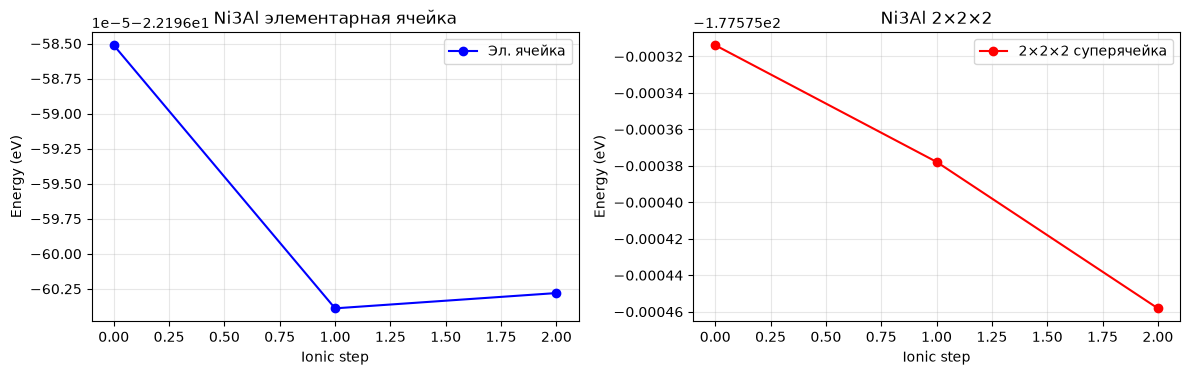

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Сравнение энергий ионных шагов: эл. ячейка vs суперячейка
energies_02 = [s['e_0_energy'] for s in Ni3Al_02_steps]
energies_uc = [s['e_0_energy'] for s in Ni3Al_01_steps]

axes[0].plot(range(len(energies_uc)), energies_uc, 'b-o', label='Эл. ячейка')
axes[0].set_xlabel('Ionic step')
axes[0].set_ylabel('Energy (eV)')
axes[0].set_title('Ni3Al элементарная ячейка')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(range(len(energies_02)), energies_02, 'r-o', label='2×2×2 суперячейка')
axes[1].set_xlabel('Ionic step')
axes[1].set_ylabel('Energy (eV)')
axes[1].set_title('Ni3Al 2×2×2')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Вклады в полную энергию

In [23]:
contribs_Ni3Al_02 = Ni3Al_02_Outcar.final_energy_contribs
contribs_Ni3Al_01 = Ni3Al_01_Outcar.final_energy_contribs

scaled = {k: v * 8 for k, v in contribs_Ni3Al_01.items()}
delta = {k: contribs_Ni3Al_02[k] - scaled[k] for k in contribs_Ni3Al_02}

rel_delta = {}
for k in delta:
    if scaled[k] != 0:
        rel_delta[k] = (delta[k] / scaled[k]) * 100
    else:
        rel_delta[k] = 0.0

df_energy_contribs_02 = pd.DataFrame([
    {'Система': 'Ni3Al эл.ячейка', **contribs_Ni3Al_01},
    {'Система': 'Ni3Al 2×2×2', **contribs_Ni3Al_02},
    {'Система': 'Абсолютное отклонение (эВ)', **delta},
    {'Система': 'Относительное отклонение (%)', **rel_delta}
])

df_energy_contribs_02

,Система,PSCENC,TEWEN,DENC,EXHF,XCENC,PAW double counting,EENTRO,EBANDS,EATOM,Ediel_sol
0,Ni3Al эл.ячейка,218.752406,-2685.33898501,-862.32984628,0.0,66.3856262,-172.3222905900002,-0.01250932,125.42446585,3287.24036057,0.0
1,Ni3Al 2×2×2,1749.81267527,-21481.86872644,-6899.0480786,0.0,531.07537147,-1378.5621495800006,-0.09970013,1003.15903189,26297.9228846,0.0
2,Абсолютное отклонение (эВ),-0.2065727300000617,0.8431536400021287,-0.4093083600000682,0.0,-0.009638129999984812,0.01617514000099618,0.0003744300000000089,-0.23669490999998288,3.9999576983973384e-08,0.0
3,Относительное отклонение (%),-0.01180402616920598,-0.003924800764022483,0.005933175712370697,0.0,-0.0018147998579820604,-0.0011733203482857208,-0.3741510329898117,-0.023589387883367143,1.5210165897724902e-10,0.0


> Сравнение энергетических вкладов для суперячейки 2×2×2 с масштабированными значениями элементарной ячейки показывает почти идеальное линейное масштабирование – отклонения не превышают 0.4%.

Небольшие расхождения (порядка 0,02–0,37%) обусловлены исключительно **различиями в численных параметрах расчёта**:
1. явное задание k-сетки вместо автоматической (отсутствие KSPACING),
2. ужесточённые критерии сходимости (EDIFF = 1e-8, EDIFFG = –0.001).

# K-точки

In [24]:
# [VASP_run_02] Кол-во K-точек
Ni3Al_02_N_KPOINTS = len(Ni3Al_02_vasprun.actual_kpoints)

# [VASP_run_02] Координаты первой k-точки по направлению
Ni3Al_02_kx, Ni3Al_02_ky, Ni3Al_02_kz = Ni3Al_02_vasprun.kpoints.kpts[0]

# [VASP_run_02] K-cетка
Ni3Al_02_kmesh = f"{int(Ni3Al_02_kx)}×{int(Ni3Al_02_ky)}×{int(Ni3Al_02_kz)}"

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_02 = SpacegroupAnalyzer(Ni3Al_02_optimized_structure).get_primitive_standard_structure()

# [VASP_run_02] K-точки высокой симметрии
Ni3Al_02_hs_points = ', '.join(HighSymmKpath(prim_02).kpath['kpoints'].keys())

In [25]:
# [VASP_run_01] Кол-во K-точек
Ni3Al_01_N_KPOINTS = len(Ni3Al_01_vasprun.actual_kpoints)

# [VASP_run_01] Координаты первой k-точки по направлению
Ni3Al_01_kx, Ni3Al_01_ky, Ni3Al_01_kz = Ni3Al_01_vasprun.kpoints.kpts[0]

# [VASP_run_01] K-cетка
Ni3Al_01_kmesh = f"{Ni3Al_01_kx}×{Ni3Al_01_ky}×{Ni3Al_01_kz}"

# [VASP_run_01] K-точки высокой симметрии
Ni3Al_01_hs_points = ', '.join(HighSymmKpath(Ni3Al_01_optimized_structure).kpath['kpoints'].keys())

In [26]:
data_kpoints_02 = {
    'Система': ['Ni3Al 2×2×2', 'Ni3Al эл.ячейка'],
    'N k-точек': [Ni3Al_02_N_KPOINTS, Ni3Al_01_N_KPOINTS],
    'K-сетка': [Ni3Al_02_kmesh , Ni3Al_01_kmesh,],
    'Высокосимм. точки': [Ni3Al_02_hs_points, Ni3Al_01_hs_points,],
}

df_kpoints_02 = pd.DataFrame(data_kpoints_02)
df_kpoints_02

,Система,N k-точек,K-сетка,Высокосимм. точки
0,Ni3Al 2×2×2,35,8×8×8,"\Gamma, X, R, M"
1,Ni3Al эл.ячейка,220,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [27]:
Ni3Al_02_nelect = int(Ni3Al_02_Outcar.nelect)
Ni3Al_01_nelect = int(Ni3Al_01_Outcar.nelect)

print(f"Ni3Al 2×2×2: {Ni3Al_02_nelect} электронов")
print(f"Ni3Al эл.ячейка: {Ni3Al_01_nelect} электронов")

Ni3Al 2×2×2: 264 электронов
Ni3Al эл.ячейка: 33 электронов


In [28]:
# [VASP_run_02] Полная DOS
Ni3Al_02_complete_dos = Ni3Al_02_vasprun.complete_dos

# [VASP_run_02] Энергетическая сетка для DOS (эВ)
Ni3Al_02_complete_dos_energy = Ni3Al_02_complete_dos.energies

# [VASP_run_02] Суммарная плотность состояний (states/eV)
Ni3Al_02_complete_dos_densities = sum(Ni3Al_02_complete_dos.densities.values())

# [VASP_run_02] Уровень Ферми (эВ)
Ni3Al_02_efermi = Ni3Al_02_vasprun.complete_dos.efermi

In [29]:
# [VASP_run_01] Полная DOS
Ni3Al_01_complete_dos = Ni3Al_01_vasprun.complete_dos

# [VASP_run_01] Энергетическая сетка для DOS (эВ)
Ni3Al_01_complete_dos_energy = Ni3Al_01_complete_dos.energies

# [VASP_run_01] Суммарная плотность состояний (states/eV)
Ni3Al_01_complete_dos_densities = sum(Ni3Al_01_complete_dos.densities.values())

# [VASP_run_01] Уровень Ферми (эВ)
Ni3Al_01_efermi = Ni3Al_01_vasprun.complete_dos.efermi

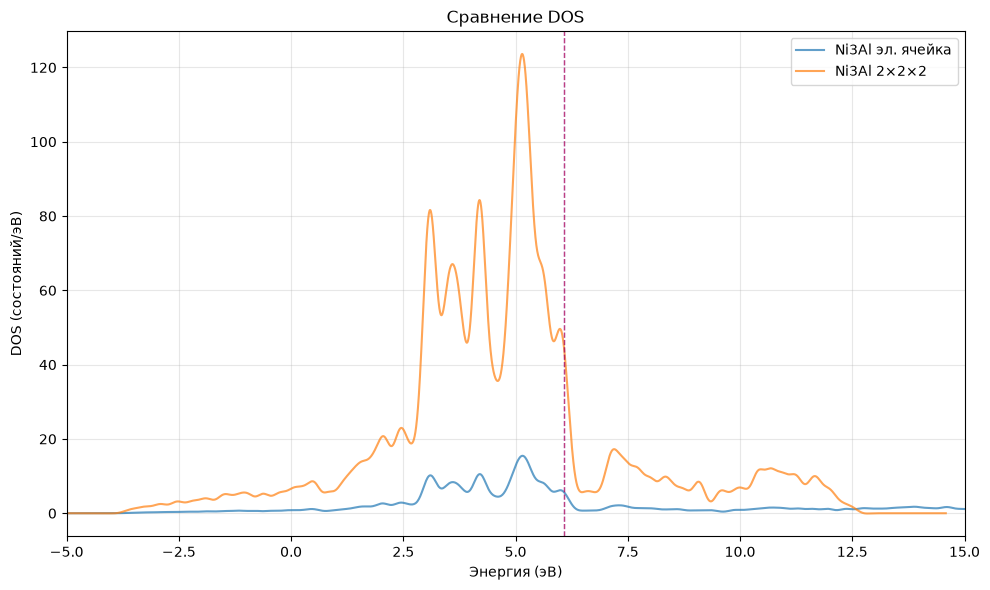

In [30]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Сравнение с Расчётом №1
axes.plot(Ni3Al_01_complete_dos_energy, Ni3Al_01_complete_dos_densities, label='Ni3Al эл. ячейка', alpha=0.7)
axes.plot(Ni3Al_02_complete_dos_energy, Ni3Al_02_complete_dos_densities, label='Ni3Al 2×2×2', alpha=0.7)
axes.axvline(Ni3Al_01_efermi, color='blue', linestyle='--', alpha=0.5, linewidth=1)
axes.axvline(Ni3Al_02_efermi, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes.set_xlabel('Энергия (эВ)')
axes.set_ylabel('DOS (состояний/эВ)')
axes.set_title('Сравнение DOS')
axes.grid(alpha=0.3)
axes.legend()

plt.xlim(-5, 15)
plt.tight_layout()
plt.show()

## Проектированный DOS (LORBIT=11)

In [31]:
# Извлекаем проектированную DOS по элементам и получаем список элементов
Ni3Al_02_pdos_element_dos = Ni3Al_02_complete_dos.get_element_dos()
Ni3Al_02_elements = list(Ni3Al_02_pdos_element_dos.keys())

# PDOS для Al и Ni
Ni3Al_02_pdos_Al = Ni3Al_02_pdos_element_dos[Ni3Al_02_elements[0]]
Ni3Al_02_pdos_Ni = Ni3Al_02_pdos_element_dos[Ni3Al_02_elements[1]]


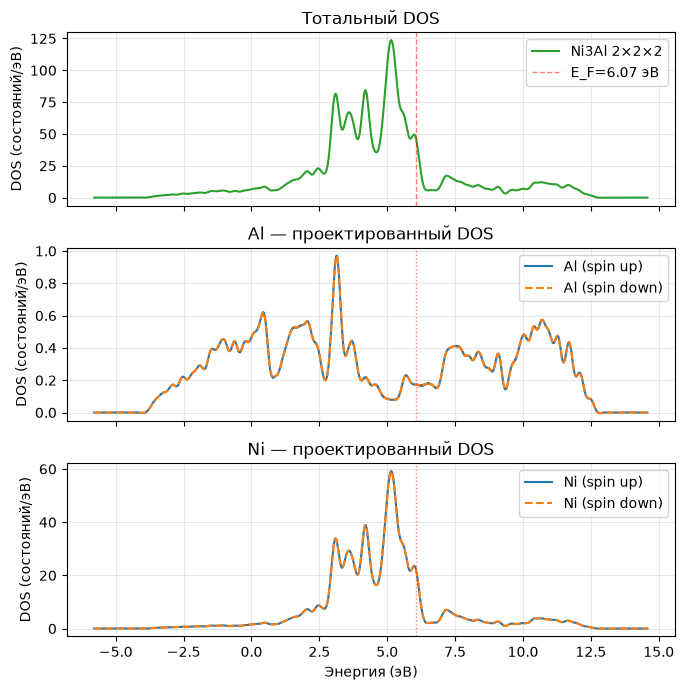

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Тотальный DOS
axes[0].plot(Ni3Al_02_complete_dos_energy, Ni3Al_02_complete_dos_densities, label='Ni3Al 2×2×2', color='tab:green')
axes[0].axvline(Ni3Al_02_efermi, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F={Ni3Al_02_efermi:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Тотальный DOS')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Al
for spin, ls in [(Spin.up, '-'), (Spin.down, '--')]:
    densities = Ni3Al_02_pdos_Al.get_densities(spin)
    energies = Ni3Al_02_pdos_Al.energies
    axes[1].plot(energies, densities, ls, label=f'Al (spin {spin.name})', linewidth=1.5)

axes[1].axvline(Ni3Al_02_efermi, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Al — проектированный DOS')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Ni
for spin, ls in [(Spin.up, '-'), (Spin.down, '--')]:
    densities = Ni3Al_02_pdos_Ni.get_densities(spin)
    energies = Ni3Al_02_pdos_Ni.energies
    axes[2].plot(energies, densities, ls, label=f'Ni (spin {spin.name})', linewidth=1.5)

axes[2].axvline(Ni3Al_02_efermi, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('Энергия (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Ni — проектированный DOS')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

График парциальной (PDOS) и полной (TDOS) плотности состояний для Ni3Al из работы "Study of structural, elastic, electronic, optical and thermal properties of Ni3Al" - [EID: 2-s2.0-80053137277](https://www.researchgate.net/publication/249616445_Study_of_structural_elastic_electronic_optical_and_thermal_properties_of_Ni3Al). Уровень Ферми установлен на нулевой энергии и отмечен вертикальной сплошной линией:

<img src="../image/image_02.png" width="700">

Расчет в статье был выполнен с помощью пакета программного обеспечения **CASTEP**. Значения файла запуска `.param` которые указаны в работе:

|                          | Ni3Al                      | Аналогичный параметр в VASP                                  |
|--------------------------|----------------------------|--------------------------------------------------------------|
| `task`                   | `GeometryOptimization`     | `IBRION`                                                     |
| `xc_functional`          | `PBE` (GGA) / `CAPZ` (LDA) | Файл POTCAR                                                  |
| `pseudopotentials`       | `ultrasoft`                | Файл POTCAR                                                  |
| `cut_off_energy`         | `660` eV                   | `ENCUT`                                                      |
| `kpoint_mp_grid`         | `8 8 8`                    | `KSPACING` или файл KPOINTS                                  |
| `opt_strategy`           | `BFGS`                     | `BFGS`                                                       |
| `etol_conv`              | `5e-6` eV/atom             | `EDIFF`,но в VASP — на всю ячейку, а не на атом              |
| `ftol_conv`              | `0.01` eV/Å                | `EDIFFG`                                                     |
| `stol_conv`              | `0.03` GPa                 | `EDIFFG`, но для максимального компонента тензора напряжений |
| `dtol_conv`              | `1e-4` Å                   | `EDIFFG`, но для максимального смещения атома                |
| `smearing_width`         | `0.3` eV                   | `SIGMA`; `ISMEAR=0`                                          |

Все остальные параметры (например, `spin_polarized`, `optimize_cell` / `ISIF`, `max_iter`, `nelm` и т.п.) в тексте статьи не указаны.

## Потенциал Хартри (LOCPOT)

In [33]:
# Средний потенциал вдоль каждой оси (1D-профиль)
avg_x = Ni3Al_02_LOCPOT.get_average_along_axis(0)
avg_y = Ni3Al_02_LOCPOT.get_average_along_axis(1)
avg_z = Ni3Al_02_LOCPOT.get_average_along_axis(2)

# Сетка вдоль осей (в долях решётки)
grid_x = Ni3Al_02_LOCPOT.get_axis_grid(0)
grid_y = Ni3Al_02_LOCPOT.get_axis_grid(1)
grid_z = Ni3Al_02_LOCPOT.get_axis_grid(2)

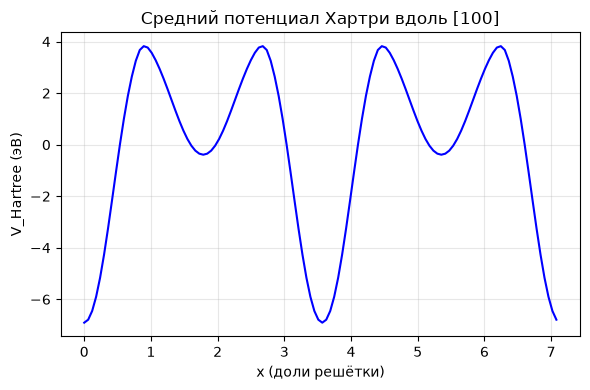

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(grid_x, avg_x, 'b-')
ax.set_xlabel('x (доли решётки)')
ax.set_ylabel('V_Hartree (эВ)')
ax.set_title('Средний потенциал Хартри вдоль [100]')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

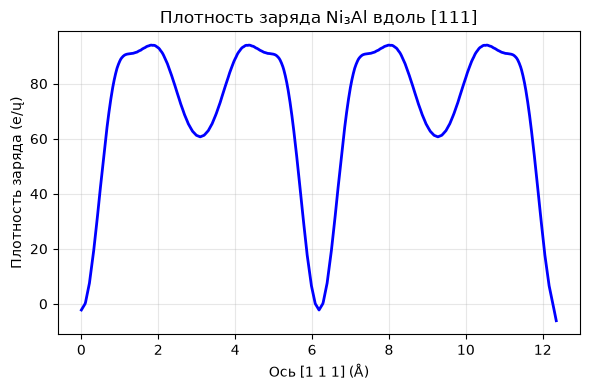

In [35]:
nx, ny, nz = Ni3Al_02_CHGCAR.data['total'].shape
grid = [np.linspace(0, 1, n, endpoint=False) for n in (nx, ny, nz)]
interp = RegularGridInterpolator(grid, Ni3Al_02_CHGCAR.data['total'], bounds_error=False, fill_value=None)

t = np.linspace(0, 1, 1000, endpoint=False)
pts = np.column_stack([t, t, t])
charge_111 = interp(pts)
dist = t * np.sqrt(3) * Ni3Al_02_a_opt

plt.figure(figsize=(6, 4))
plt.plot(dist, charge_111, 'b-', linewidth=2)
plt.xlabel('Ось [1 1 1] (Å)')
plt.ylabel('Плотность заряда (e/ų)')
plt.title('Плотность заряда Ni₃Al вдоль [111]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График полной валентной электронной плотности для Ni3Al в точке Γ вдоль направления [111] при различных значениях давления из работы "Study of structural, elastic, electronic, optical and thermal properties of Ni3Al" – [EID: 2-s2.0-80053137277](https://www.researchgate.net/publication/249616445_Study_of_structural_elastic_electronic_optical_and_thermal_properties_of_Ni3Al):

<img src="../image/image_03.png" width="650">

# Сводная таблица

In [36]:
df_run2 = pd.DataFrame([
    {'Система': 'Ni3Al эл.ячейка', 'Электронов': Ni3Al_01_nelect, 'E_F (эВ)': Ni3Al_01_efermi, 'Магн. момент (μB)': Ni3Al_01_total_mag, 'Полная энергия (эВ)': TOTEN_Ni3Al_01},
    {'Система': 'Ni3Al 2×2×2', 'Электронов': Ni3Al_02_nelect, 'E_F (эВ)': Ni3Al_02_efermi, 'Магн. момент (μB)': Ni3Al_02_total_mag, 'Полная энергия (эВ)': TOTEN_Ni3Al_02},
])

df_run2 = df_run2.merge(df_crystal_02)
df_run2 = df_run2.merge(df_kpoints_02)
df_run2

,Система,Электронов,E_F (эВ),Магн. момент (μB),Полная энергия (эВ),Группа,a старт. (Å),a опт. (Å),Δa (%),V старт. (Å³),V опт. (Å³),ΔV (%),N k-точек,K-сетка,Высокосимм. точки
0,Ni3Al эл.ячейка,33,6.07223669,0.0001541,-22.1966028,Pm-3m,3.57,3.568904653078676,-0.030681986591707525,45.499292999999994,45.457425587449116,-0.09201772113443318,220,18×18×18,"\Gamma, X, R, M"
1,Ni3Al 2×2×2,264,6.07098069,-0.0018575,-177.57545814,Pm-3m,7.14,7.138090177923622,-0.02674820835263334,363.99434399999996,363.70233622420346,-0.08022316297214,35,8×8×8,"\Gamma, X, R, M"
